# V4a.1 — Held-out evaluation для Logistic Preference Model

Цель ноутбука — проверить, умеет ли online `Logistic Preference Model` обобщать A/B-опыт пользователя на новые пары, которых модель не видела в процессе персонализации.

Важно: модель **сбрасывается для каждого нового пользователя**. Она обучается только внутри одной персональной A/B-сессии, после чего проверяется на held-out парах этого же synthetic user.


## Логика эксперимента

Для каждого synthetic user:

1. запускается A/B-сессия на `25` шагов;
2. Pair Generator фиксирован: `Semantic active v3`;
3. Preference Model наблюдает `(z_A, z_B, choice)` и обновляет свой `z_pref` online;
4. после сессии веса модели **не сбрасываются**;
5. генерируются новые held-out A/B-пары;
6. synthetic user выбирает A/B;
7. модель предсказывает `P(A > B)` без дообучения;
8. считаются `heldout_accuracy`, `heldout_log_loss` и `cosine_to_target`.


In [1]:
from personalization.plotting import use_article_style
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from personalization.synthetic_dataset import load_synthetic_users_dataset
from personalization.preference_model_heldout import (
    run_preference_model_heldout_batch_v4a1,
    summarize_v4a1_by_target_mode,
    summarize_v4a1_heldout_by_source,
    save_v4a1_outputs,
)

use_article_style()


In [2]:
# Article-ready light theme
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "legend.facecolor": "white",
    "legend.edgecolor": "0.75",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

TARGET_MODE_DISPLAY = {
    "random8d": "Random 8D",
    "semantic4d": "Semantic 4D",
    "semantic6d": "Semantic 6D",
    "archetype8d": "Archetype 8D",
}

TARGET_MODE_ORDER = ["random8d", "semantic4d", "semantic6d", "archetype8d"]


## Загрузка fixed synthetic user dataset

In [3]:
dataset_path = ROOT / "outputs" / "datasets" / "synthetic_users_v21.csv"
dataset = load_synthetic_users_dataset(dataset_path)

print(dataset_path)
dataset["target_mode"].value_counts()


C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\datasets\synthetic_users_v21.csv


target_mode
random8d       100
semantic4d     100
semantic6d     100
archetype8d    100
Name: count, dtype: int64

## Запуск V4a.1 held-out evaluation

In [4]:
sessions, train_steps, heldout_pairs = run_preference_model_heldout_batch_v4a1(
    dataset=dataset,
    n_steps=25,
    n_heldout_pairs=100,
    pair_strategy="semantic_active_v21",
    step_scale=0.6,
    heuristic_lr=0.25,
    model_lr=0.06,
    model_temperature=0.75,
    model_l2=0.003,
    model_feature_weight="uniform",
)

summary = summarize_v4a1_by_target_mode(sessions)
source_summary = summarize_v4a1_heldout_by_source(heldout_pairs)

summary


,target_mode,users,mean_initial_distance,heuristic_mean_final_distance,model_mean_final_distance,mean_final_model_cosine_to_target,mean_train_accuracy,mean_train_log_loss_before,mean_train_log_loss_after,mean_heldout_accuracy,mean_heldout_log_loss,mean_heldout_confidence,mean_heldout_margin
0,archetype8d,100,1.102635,0.371572,0.529492,0.927321,0.5332,0.739182,0.626442,0.6150,0.681051,0.166219,0.190805
1,random8d,100,2.212002,1.512784,1.708623,0.684178,0.4136,0.848222,0.714763,0.5263,0.737925,0.244433,0.493921
2,semantic4d,100,1.731930,0.414821,0.854659,0.966305,0.3988,0.896257,0.754947,0.5450,0.724353,0.255077,0.214717
3,semantic6d,100,2.251218,0.554277,1.222919,0.964520,0.3456,1.012627,0.852472,0.4961,0.847920,0.322446,0.281904


In [5]:
output_dir = ROOT / "outputs" / "metrics"
figure_dir = ROOT / "outputs" / "figures"
table_dir = ROOT / "outputs" / "tables"

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

save_v4a1_outputs(
    sessions=sessions,
    train_steps=train_steps,
    heldout_pairs=heldout_pairs,
    summary=summary,
    source_summary=source_summary,
    output_dir=output_dir,
    prefix="notebook_v4a1_preference_model_heldout",
)

summary.to_csv(table_dir / "article_v4a1_heldout_summary.csv", index=False)
source_summary.to_csv(table_dir / "article_v4a1_heldout_by_source.csv", index=False)

print("Saved metrics to:", output_dir)
print("Saved tables to:", table_dir)


Saved metrics to: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\metrics
Saved tables to: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\tables


## Сводная таблица по режимам target

In [6]:
display_cols = [
    "target_mode",
    "users",
    "heuristic_mean_final_distance",
    "model_mean_final_distance",
    "mean_final_model_cosine_to_target",
    "mean_train_accuracy",
    "mean_train_log_loss_before",
    "mean_train_log_loss_after",
    "mean_heldout_accuracy",
    "mean_heldout_log_loss",
]

summary_display = summary[display_cols].copy()
summary_display["target_mode"] = summary_display["target_mode"].map(TARGET_MODE_DISPLAY)
summary_display


,target_mode,users,heuristic_mean_final_distance,model_mean_final_distance,mean_final_model_cosine_to_target,mean_train_accuracy,mean_train_log_loss_before,mean_train_log_loss_after,mean_heldout_accuracy,mean_heldout_log_loss
0,Archetype 8D,100,0.371572,0.529492,0.927321,0.5332,0.739182,0.626442,0.6150,0.681051
1,Random 8D,100,1.512784,1.708623,0.684178,0.4136,0.848222,0.714763,0.5263,0.737925
2,Semantic 4D,100,0.414821,0.854659,0.966305,0.3988,0.896257,0.754947,0.5450,0.724353
3,Semantic 6D,100,0.554277,1.222919,0.964520,0.3456,1.012627,0.852472,0.4961,0.847920


## График 1 — близость направления модели к скрытому target

`Cosine similarity` показывает, насколько направление `z_pref`, восстановленное Preference Model, совпадает со скрытым target-вектором synthetic user. Значение около `1.0` означает, что модель хорошо восстановила направление вкуса пользователя.


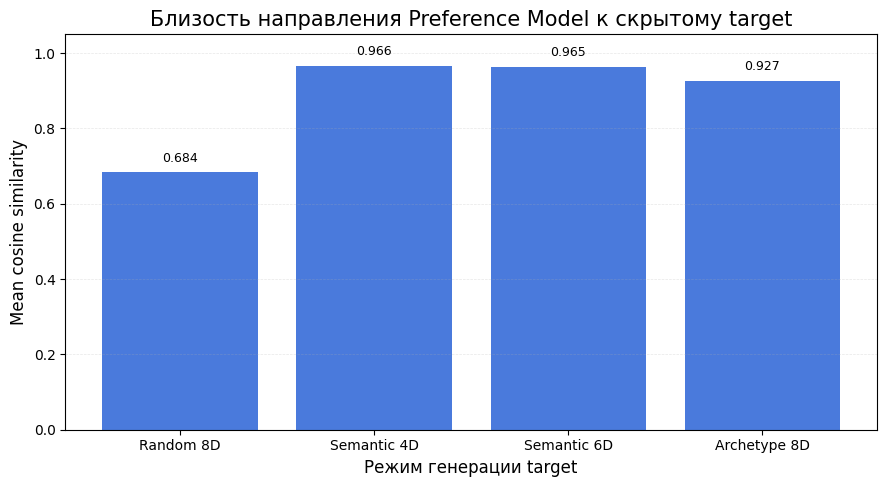

In [7]:
plot_df = summary.copy()
plot_df["target_label"] = plot_df["target_mode"].map(TARGET_MODE_DISPLAY)
plot_df["target_mode"] = pd.Categorical(plot_df["target_mode"], TARGET_MODE_ORDER, ordered=True)
plot_df = plot_df.sort_values("target_mode")

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.bar(plot_df["target_label"], plot_df["mean_final_model_cosine_to_target"], alpha=0.9)
ax.set_title("Близость направления Preference Model к скрытому target")
ax.set_xlabel("Режим генерации target")
ax.set_ylabel("Mean cosine similarity")
ax.set_ylim(0.0, 1.05)
ax.grid(True, axis="y", alpha=0.3, linestyle="--")

for i, value in enumerate(plot_df["mean_final_model_cosine_to_target"]):
    ax.text(i, value + 0.02, f"{value:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
fig.savefig(figure_dir / "article_v4a1_cosine_to_target.png", dpi=300, bbox_inches="tight")
plt.show()


## График 2 — held-out accuracy

Эта метрика показывает, насколько модель после персональной A/B-сессии способна предсказывать выбор synthetic user на новых, ранее не виденных парах. Accuracy используется как диагностическая метрика, а не как единственный критерий успеха: active pairs могут быть специально сложными, а synthetic utility не обязана совпадать с линейными предположениями модели.


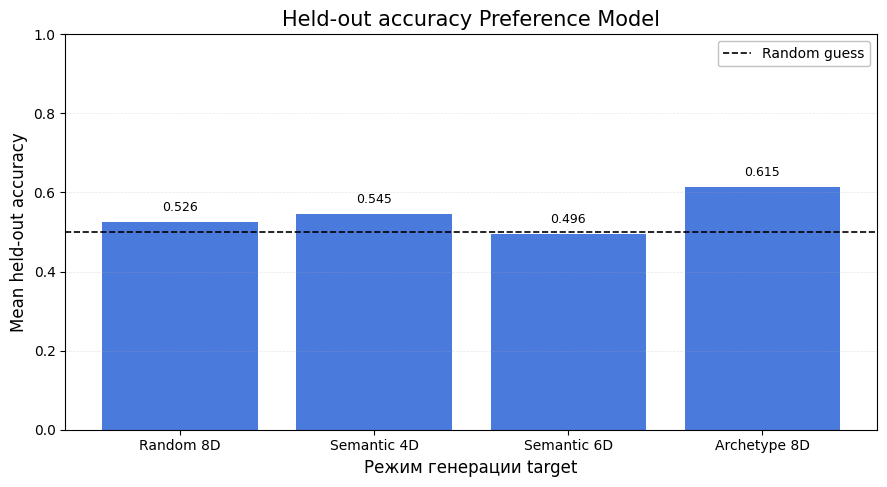

In [8]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.bar(plot_df["target_label"], plot_df["mean_heldout_accuracy"], alpha=0.9)
ax.axhline(0.5, color="black", linewidth=1.2, linestyle="--", label="Random guess")
ax.set_title("Held-out accuracy Preference Model")
ax.set_xlabel("Режим генерации target")
ax.set_ylabel("Mean held-out accuracy")
ax.set_ylim(0.0, 1.0)
ax.grid(True, axis="y", alpha=0.3, linestyle="--")
ax.legend(frameon=True)

for i, value in enumerate(plot_df["mean_heldout_accuracy"]):
    ax.text(i, value + 0.02, f"{value:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
fig.savefig(figure_dir / "article_v4a1_heldout_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()


## График 3 — final distance: heuristic update vs Preference Model

Этот график сравнивает итоговую точность двух оценок preference state: эвристического `z_mean` и вектора `z_pref`, выученного Logistic Preference Model.


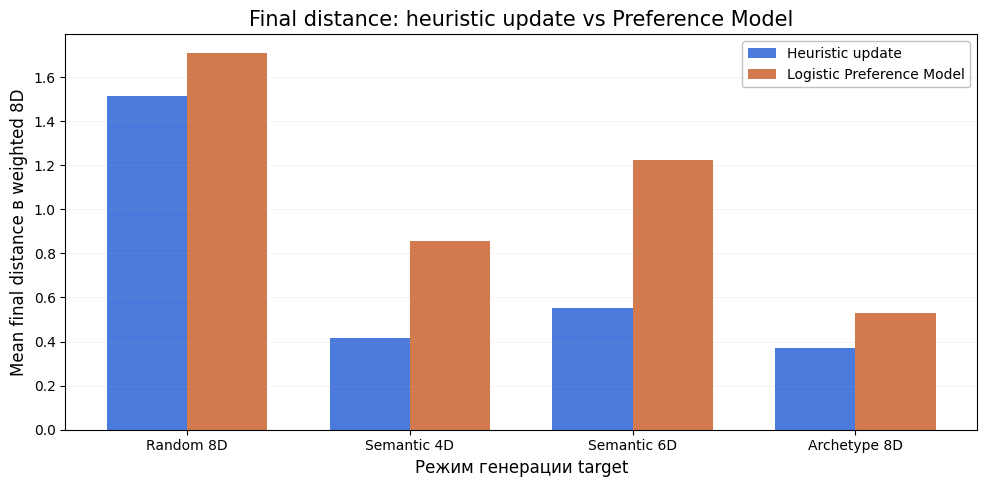

In [9]:
x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.bar(
    x - width / 2,
    plot_df["heuristic_mean_final_distance"],
    width=width,
    label="Heuristic update",
    alpha=0.9,
)
ax.bar(
    x + width / 2,
    plot_df["model_mean_final_distance"],
    width=width,
    label="Logistic Preference Model",
    alpha=0.9,
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["target_label"], rotation=0, ha="center")
ax.set_title("Final distance: heuristic update vs Preference Model")
ax.set_xlabel("Режим генерации target")
ax.set_ylabel("Mean final distance в weighted 8D")
ax.grid(True, axis="y", alpha=0.3, linestyle="--")
ax.legend(frameon=True)

plt.tight_layout()
fig.savefig(figure_dir / "article_v4a1_final_distance_heuristic_vs_model.png", dpi=300, bbox_inches="tight")
plt.show()


## Held-out качество по типу новых вопросов

In [10]:
source_summary_display = source_summary.copy()
source_summary_display["target_mode"] = source_summary_display["target_mode"].map(TARGET_MODE_DISPLAY)
source_summary_display


,target_mode,source_group,pairs,heldout_accuracy,heldout_log_loss,mean_margin,mean_p_a
0,Archetype 8D,axis,1998,0.635135,0.673148,0.161020,0.500620
1,Archetype 8D,random,3931,0.584330,0.683390,0.194656,0.500911
2,Archetype 8D,semantic6d,4071,0.634733,0.682670,0.201705,0.497083
3,Random 8D,axis,1991,0.499749,0.733489,0.579236,0.502515
4,Random 8D,random,4011,0.474695,0.760700,0.698024,0.501364
5,Random 8D,semantic6d,3998,0.591296,0.717285,0.246667,0.501465
6,Semantic 4D,axis,2075,0.548916,0.711682,0.172662,0.502275
7,Semantic 4D,random,3956,0.521992,0.728103,0.214646,0.497593
8,Semantic 4D,semantic6d,3969,0.565886,0.727240,0.236774,0.501346
9,Semantic 6D,axis,1957,0.509453,0.784428,0.224963,0.501319


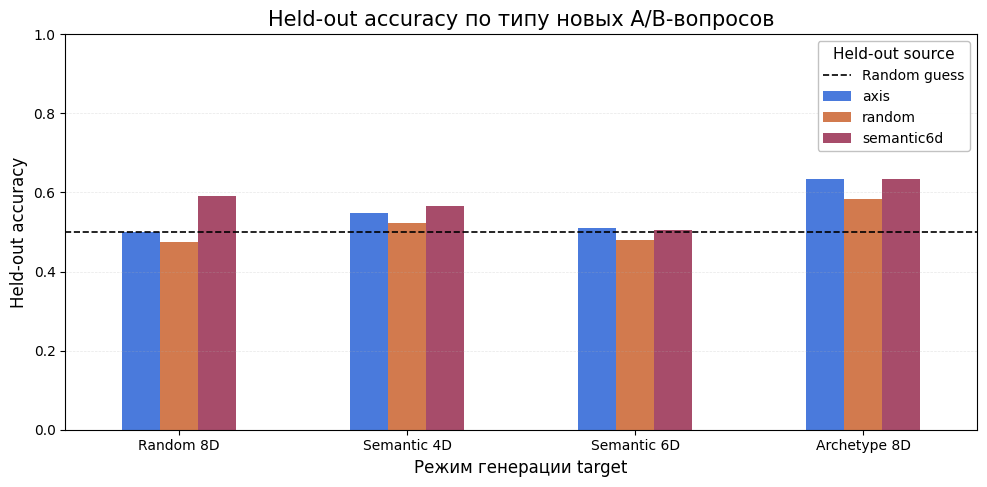

In [11]:
pivot_acc = source_summary.pivot(
    index="target_mode",
    columns="source_group",
    values="heldout_accuracy",
).reindex(TARGET_MODE_ORDER)

pivot_acc.index = [TARGET_MODE_DISPLAY.get(x, x) for x in pivot_acc.index]

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
pivot_acc.plot(kind="bar", ax=ax, alpha=0.9)
ax.axhline(0.5, color="black", linewidth=1.2, linestyle="--", label="Random guess")
ax.set_title("Held-out accuracy по типу новых A/B-вопросов")
ax.set_xlabel("Режим генерации target")
ax.set_ylabel("Held-out accuracy")
ax.set_ylim(0.0, 1.0)
ax.grid(True, axis="y", alpha=0.3, linestyle="--")
ax.legend(title="Held-out source", frameon=True)
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
fig.savefig(figure_dir / "article_v4a1_heldout_accuracy_by_source.png", dpi=300, bbox_inches="tight")
plt.show()


## Вывод по V4a.1 held-out evaluation

Held-out evaluation показал, что Logistic Preference Model способна извлекать направление скрытого preference target из короткой A/B-сессии. Это подтверждается высокой cosine similarity между вектором модели и скрытым target, особенно в режимах `Semantic 4D`, `Semantic 6D` и `Archetype 8D`.

Однако прямая замена heuristic preference state на вектор Logistic Preference Model пока не улучшает final distance. Несмотря на правильное направление, модель хуже калибрует масштаб preference vector, поэтому итоговое расстояние до target оказывается выше, чем у текущего heuristic update.

Held-out accuracy выше случайного уровня для `Archetype 8D`, что показывает способность модели переносить выученный preference pattern на новые A/B-пары. При этом accuracy остаётся нестабильной по режимам, поэтому её следует рассматривать как вспомогательную диагностическую метрику, а не как главный критерий качества.

Таким образом, V4a.1 подтверждает, что Preference Model полезна как источник направления предпочтений, но пока не должна напрямую заменять текущий heuristic update. Следующим шагом является scale calibration: использование модели для определения направления, а эвристического state или отдельной процедуры — для выбора масштаба.